<a href="https://colab.research.google.com/github/Taheri1400/deep-learning-projects/blob/main/CCFD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
os.environ['KERAS_BACKEND'] = 'tensorflow'

In [4]:
df = pd.read_csv('/content/drive/MyDrive/creditcard.csv')
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [ ]:
df.isnull().sum()/len(df) * 100

,0
Time,0.0
V1,0.0
V2,0.0
V3,0.0
V4,0.0
V5,0.0
V6,0.0
V7,0.0
V8,0.0
V9,0.0


In [ ]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [ ]:
df['Class'].value_counts()

,count
Class,
0,284315
1,492


In [ ]:
df[df['Class'] == 1]['Amount']

,Amount
541,0.00
623,529.00
4920,239.93
6108,59.00
6329,1.00
...,...
279863,390.00
280143,0.76
280149,77.89
281144,245.00


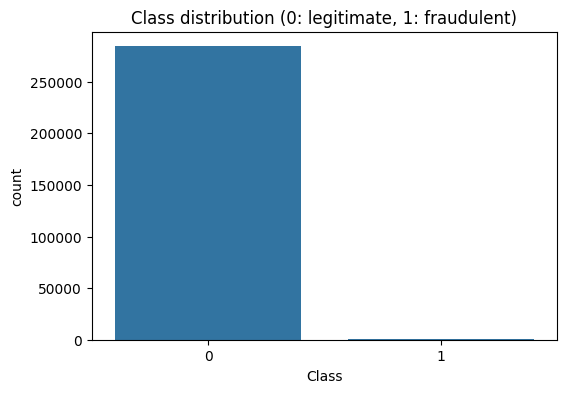

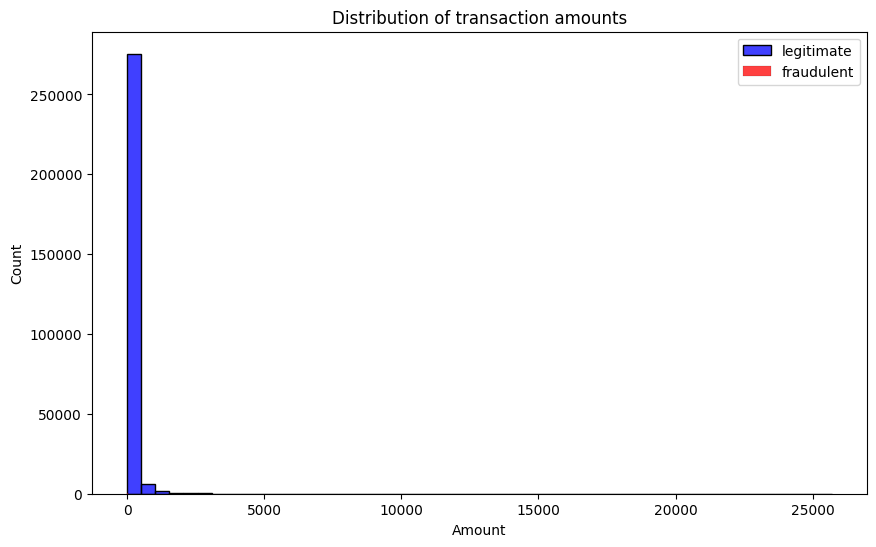

In [ ]:

plt.figure(figsize=(6, 4))
sns.countplot(x='Class', data=df)
plt.title('Class distribution (0: legitimate, 1: fraudulent)')
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(df[df['Class'] == 0]['Amount'], bins=50, color='blue', label='legitimate')
sns.histplot(df[df['Class'] == 1]['Amount'], bins=50, color='red', label='fraudulent')
plt.legend()
plt.title('Distribution of transaction amounts')
plt.show()

In [ ]:
minority_class = df['Class'].value_counts().min()
majority_class = df['Class'].value_counts().max()
cir = majority_class / minority_class
print(cir)

577.8760162601626


# Preprocessing

## Normalization

In [6]:
from sklearn.preprocessing import StandardScaler

X = df.drop('Class', axis=1)
y = df['Class']

scaler = StandardScaler()
X[['Time', 'Amount']] = scaler.fit_transform(X[['Time', 'Amount']])

X[:5]


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,-1.996583,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0.244964
1,-1.996583,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.342475
2,-1.996562,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,1.160686
3,-1.996562,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0.140534
4,-1.996541,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,-0.073403


## Train Test Validation Split

In [7]:
from sklearn.model_selection import train_test_split

X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.2, random_state=32)

print(f'shape of X train : {X_train.shape}')
print(f'shape of y train : {y_train.shape}')

print(f'shape of X validation : {X_val.shape}')
print(f'shape of y validation : {y_val.shape}')

print(f'shape of X test : {X_test.shape}')
print(f'shape of y test : {y_test.shape}')



shape of X train : (182276, 30)
shape of y train : (182276,)
shape of X validation : (45569, 30)
shape of y validation : (45569,)
shape of X test : (56962, 30)
shape of y test : (56962,)


## Balance the data

In [8]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"number of training samples after SMOTE: {len(X_train_resampled)}")
print(f"Class Distribution after SMOTE:\n{pd.Series(y_train_resampled).value_counts()}")

number of training samples after SMOTE: 363940
Class Distribution after SMOTE:
Class
0    181970
1    181970
Name: count, dtype: int64


# Design the Model

In [9]:
import keras
from keras import layers

def create_model(input_shape, units1=64, units2=32, units3=16, dropout_rate=0.2, optimizer='adam'):
    model = keras.Sequential([
        layers.Input(shape=(input_shape,)),
        layers.Dense(units1, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(units2, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(units3, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model

In [ ]:
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import GridSearchCV

In [ ]:
!pip install -U scikit-learn scikeras

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 83.7 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


In [ ]:
!pip install scikeras

In [10]:
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [ ]:
# @title
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import GridSearchCV
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

clf = KerasClassifier(
    model=create_model,
    input_shape=X_train_resampled.shape[1],
    epochs=10,
    batch_size=32,
    verbose=0,
    callbacks=[early_stopping]
)

param_grid = {
    'model__units1': [32, 64],
    'model__units2': [16, 32],
    'model__units3': [8, 16],
    'model__dropout_rate': [0.2, 0.3],
    'model__optimizer': ['adam', 'rmsprop'],
    'batch_size': [32, 64],
    'epochs': [10, 20]
}

grid = GridSearchCV(estimator=clf, param_grid=param_grid, cv=3, scoring='f1', n_jobs=-1)
grid_result = grid.fit(X_train_resampled, y_train_resampled)

print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))

In [ ]:
Best: 0.999709 using {'batch_size': 64, 'epochs': 20, 'model__dropout_rate': 0.2, 'model__optimizer': 'adam', 'model__units1': 64, 'model__units2': 16, 'model__units3': 16}



In [11]:
model = create_model(X_train_resampled.shape[1], 64, 16, 16, 0.2, 'adam')
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,313 (12.94 KB)

 Trainable params: 3,313 (12.94 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
history = model.fit(
    X_train_resampled, y_train_resampled,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/20
5687/5687 ━━━━━━━━━━━━━━━━━━━━ 25s 3ms/step - accuracy: 0.9863 - loss: 0.0378 - val_accuracy: 0.9969 - val_loss: 0.0128
Epoch 2/20
5687/5687 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - accuracy: 0.9979 - loss: 0.0083 - val_accuracy: 0.9978 - val_loss: 0.0114
Epoch 3/20
5687/5687 ━━━━━━━━━━━━━━━━━━━━ 21s 4ms/step - accuracy: 0.9986 - loss: 0.0059 - val_accuracy: 0.9987 - val_loss: 0.0104
Epoch 4/20
5687/5687 ━━━━━━━━━━━━━━━━━━━━ 43s 4ms/step - accuracy: 0.9989 - loss: 0.0051 - val_accuracy: 0.9986 - val_loss: 0.0106
Epoch 5/20
5687/5687 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - accuracy: 0.9990 - loss: 0.0042 - val_accuracy: 0.9987 - val_loss: 0.0097
Epoch 6/20
5687/5687 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - accuracy: 0.9992 - loss: 0.0037 - val_accuracy: 0.9989 - val_loss: 0.0111
Epoch 7/20
5687/5687 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - accuracy: 0.9992 - loss: 0.0039 - val_accuracy: 0.9987 - val_loss: 0.0100
Epoch 8/20
5687/5687 ━━━━━━━━━━━━━━━━━━━━ 21s 4ms/step - accuracy: 0.9992 - loss: 0

# Evaluation Metrics

## predict data with our model

In [16]:
y_train_pre = np.where(model.predict(X_train) > 0.5, 1, 0)
y_train_resampled_pre = np.where(model.predict(X_train_resampled) > 0.5, 1, 0)
y_val_pre = np.where(model.predict(X_val) > 0.5, 1, 0)
y_test_pre = np.where(model.predict(X_test) > 0.5, 1, 0)

5697/5697 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step
11374/11374 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step
1425/1425 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1781/1781 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step


In [17]:
y_train_pre

array([[0],
       [0],
       [0],
       ...,
       [0],
       [0],
       [0]])

## F1-Score

In [18]:
from sklearn.metrics import f1_score, classification_report, roc_auc_score, confusion_matrix, accuracy_score

print(f'The f1-Score for train data is : {f1_score(y_train_pre, y_train)}')
print(f'The f1-Score for train resampled data is : {f1_score(y_train_resampled_pre, y_train_resampled)}')
print(f'The f1-Score for validation data is : {f1_score(y_val_pre, y_val)}')
print(f'The f1-Score for test data is : {f1_score(y_test_pre, y_test)}')

The f1-Score for train data is : 0.8869565217391304
The f1-Score for train resampled data is : 0.9997857248817367
The f1-Score for validation data is : 0.7979274611398963
The f1-Score for test data is : 0.7567567567567568


## Accuracy Score

In [19]:
print(f'The accuracy_score for train data is : {accuracy_score(y_train_pre, y_train)}')
print(f'The accuracy_score for train resampled data is : {accuracy_score(y_train_resampled_pre, y_train_resampled)}')
print(f'The accuracy_scoree for validation data is : {accuracy_score(y_val_pre, y_val)}')
print(f'The accuracy_score for test data is : {accuracy_score(y_test_pre, y_test)}')

The accuracy_score for train data is : 0.9995720775088328
The accuracy_score for train resampled data is : 0.99978567895807
The accuracy_scoree for validation data is : 0.9991441550176655
The accuracy_score for test data is : 0.9990519995786665


## Classification Report

In [20]:
print(f'The classification report for train data is : \n{classification_report(y_train_pre, y_train)}')
print(f'The classification report for train resampled data is : \n{classification_report(y_train_resampled_pre, y_train_resampled)}')
print(f'The classification report for validation data is : \n{classification_report(y_val_pre, y_val)}')
print(f'The classification report for test data is : \n{classification_report(y_test_pre, y_test)}')

The classification report for train data is : 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    181892
           1       1.00      0.80      0.89       384

    accuracy                           1.00    182276
   macro avg       1.00      0.90      0.94    182276
weighted avg       1.00      1.00      1.00    182276

The classification report for train resampled data is : 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    181892
           1       1.00      1.00      1.00    182048

    accuracy                           1.00    363940
   macro avg       1.00      1.00      1.00    363940
weighted avg       1.00      1.00      1.00    363940

The classification report for validation data is : 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     45464
           1       0.88      0.73      0.80       105

    accuracy              

## Confusion Matrix

In [21]:
print(f'The confusion_matrix for train data is : \n{confusion_matrix(y_train_pre, y_train)}')
print(f'The confusion_matrix for train resampled data is : \n{confusion_matrix(y_train_resampled_pre, y_train_resampled)}')
print(f'The confusion_matrix report for validation data is : \n{confusion_matrix(y_val_pre, y_val)}')
print(f'The confusion_matrix report for test data is : \n{confusion_matrix(y_test_pre, y_test)}')

The confusion_matrix for train data is : 
[[181892      0]
 [    78    306]]
The confusion_matrix for train resampled data is : 
[[181892      0]
 [    78 181970]]
The confusion_matrix report for validation data is : 
[[45453    11]
 [   28    77]]
The confusion_matrix report for test data is : 
[[56824    14]
 [   40    84]]


In [23]:
confusion_matrix(y_test, y_test_pre)

array([[56824,    40],
       [   14,    84]])

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.68      0.86      0.76        98

    accuracy                           1.00     56962
   macro avg       0.84      0.93      0.88     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC Score: 0.9282197121955141


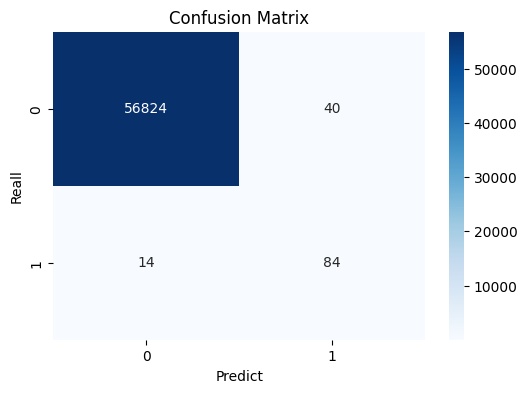

In [22]:

print("Classification Report:\n", classification_report(y_test, y_test_pre))
print("ROC-AUC Score:", roc_auc_score(y_test, y_test_pre))

# ماتریس درهم‌ریختگی
cm = confusion_matrix(y_test, y_test_pre)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predict')
plt.ylabel('Reall')
plt.show()

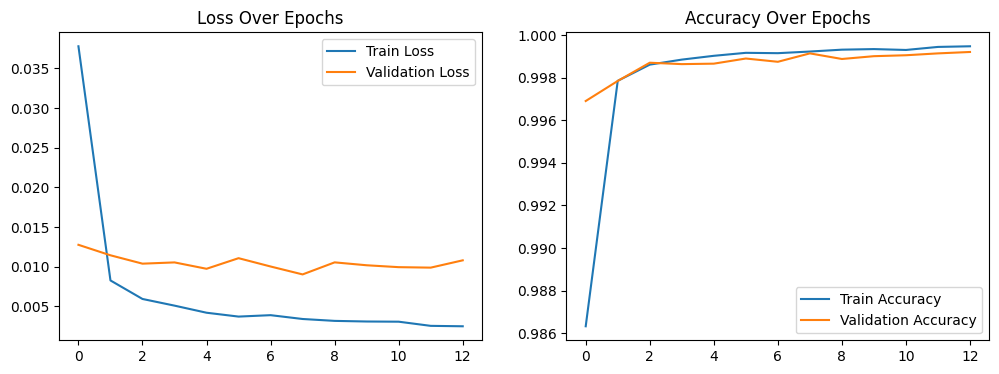

In [25]:
# Plot Loss
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Over Epochs')
plt.legend()
plt.show()

11374/11374 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step
1425/1425 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1781/1781 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


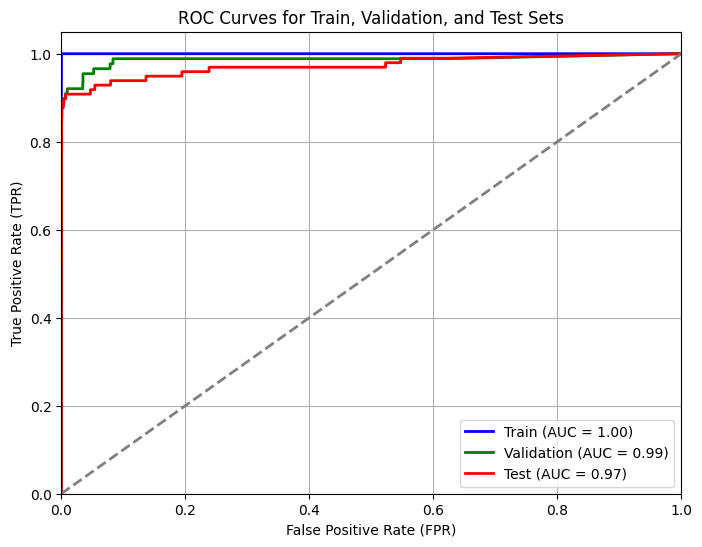

AUC for Train: 1.00
AUC for Validation: 0.99
AUC for Test: 0.97


In [26]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import numpy as np

# Function to calculate and plot ROC-AUC
def plot_roc_curve(model, X, y, label, color):
    # Predict probabilities
    y_pred_proba = model.predict(X).ravel()

    # Calculate False Positive Rate (FPR) and True Positive Rate (TPR)
    fpr, tpr, _ = roc_curve(y, y_pred_proba)

    # Calculate AUC
    roc_auc = auc(fpr, tpr)

    # Plot ROC curve
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{label} (AUC = {roc_auc:.2f})')
    return fpr, tpr, roc_auc

# Plotting
plt.figure(figsize=(8, 6))

# Calculate and plot ROC for X_train_resampled
fpr_train, tpr_train, auc_train = plot_roc_curve(model, X_train_resampled, y_train_resampled, 'Train', 'blue')

# Calculate and plot ROC for X_val
fpr_val, tpr_val, auc_val = plot_roc_curve(model, X_val, y_val, 'Validation', 'green')

# Calculate and plot ROC for X_test
fpr_test, tpr_test, auc_test = plot_roc_curve(model, X_test, y_test, 'Test', 'red')

# Reference line (random model)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2)

# Chart settings
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curves for Train, Validation, and Test Sets')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Print AUC values
print(f"AUC for Train: {auc_train:.2f}")
print(f"AUC for Validation: {auc_val:.2f}")
print(f"AUC for Test: {auc_test:.2f}")

# Save the Model or Load it

In [27]:
model.save('CCFD_model_best_with_grid_search.h5')

In [28]:
from tensorflow.keras.models import load_model
model = load_model('CCFD_model_best_with_grid_search.h5')